**Carga y preprocesamiento de dato**

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import (adjusted_rand_score, v_measure_score,
                             silhouette_score, davies_bouldin_score)

# 1. Carga y preprocesamiento de datos
# La estandarización es crítica para modelos basados en distancia (K-means, DBSCAN)
data = load_iris()
X = data.data
y_true = data.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**Método del Codo (Elbow Method)**

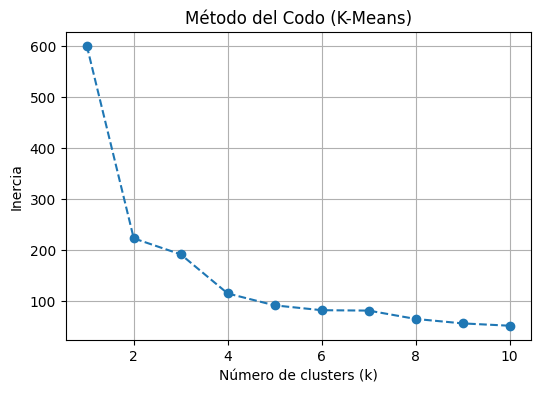

In [10]:
# 2. Método del Codo (Elbow Method) para K-Means
def plot_elbow_method(X):
    inertias = []
    K_range = range(1, 11)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)

    plt.figure(figsize=(6, 4))
    plt.plot(K_range, inertias, marker='o', linestyle='--')
    plt.title('Método del Codo (K-Means)')
    plt.xlabel('Número de clusters (k)')
    plt.ylabel('Inercia')
    plt.grid(True)
    plt.show()

# Ejecutar método del codo (Revela que k=3 es el punto de inflexión óptimo)
plot_elbow_method(X_scaled)

1. **OPTIMIZACIÓN K-MEANS**

In [11]:
# 1. OPTIMIZACIÓN K-MEANS
print("\n=== OPTIMIZACIÓN K-MEANS ===")
k_range = range(2, 6)
results_kmeans = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    results_kmeans.append({
        'k': k,
        'ARI': adjusted_rand_score(y_true, labels),
        'V-measure': v_measure_score(y_true, labels),
        'Silhouette': silhouette_score(X_scaled, labels),
        'Davies-Bouldin': davies_bouldin_score(X_scaled, labels),
        'Inercia': kmeans.inertia_
    })
df_km = pd.DataFrame(results_kmeans)
print(df_km.to_string(index=False))
best_k = df_km.loc[df_km['ARI'].idxmax(), 'k']
print(f"\nMejor k: {int(best_k)}")


=== OPTIMIZACIÓN K-MEANS ===
 k      ARI  V-measure  Silhouette  Davies-Bouldin    Inercia
 2 0.568116   0.733680    0.581750        0.593313 222.361705
 3 0.620135   0.659487    0.459948        0.833595 139.820496
 4 0.472818   0.597298    0.386941        0.869814 114.092547
 5 0.434819   0.615387    0.345901        0.948317  90.927514

Mejor k: 3


2. **OPTIMIZACIÓN DBSCAN**

In [12]:
# 2. OPTIMIZACIÓN DBSCAN
print("\n=== OPTIMIZACIÓN DBSCAN ===")
eps_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]
min_samples_values = [3, 5, 7, 10]
results_dbscan = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters >= 2:
            results_dbscan.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'ARI': adjusted_rand_score(y_true, labels),
                'V-measure': v_measure_score(y_true, labels),
                'Silhouette': silhouette_score(X_scaled, labels),
                'Davies-Bouldin': davies_bouldin_score(X_scaled, labels)
            })
df_db = pd.DataFrame(results_dbscan)
print(df_db.to_string(index=False))
best_db = df_db.loc[df_db['ARI'].idxmax()]
print(f"\nMejor: eps={best_db['eps']}, min_samples={int(best_db['min_samples'])}")



=== OPTIMIZACIÓN DBSCAN ===
 eps  min_samples  n_clusters      ARI  V-measure  Silhouette  Davies-Bouldin
 0.3            3          10 0.173758   0.402864   -0.147300        2.356784
 0.3            5           3 0.087595   0.278307   -0.194195        2.141522
 0.3            7           2 0.064077   0.222863    0.175098        0.757580
 0.5            3           7 0.452575   0.516839    0.159710        2.188298
 0.5            5           2 0.442099   0.511430    0.356516        7.124057
 0.5            7           5 0.468338   0.553641    0.139148        2.847022
 0.5           10           3 0.279191   0.465229    0.009426        2.217003
 0.7            3           2 0.550317   0.685822    0.508067        3.275691
 0.7            5           2 0.540077   0.671165    0.523401        2.435782
 0.7            7           2 0.505269   0.587611    0.463134        7.355572
 0.7           10           2 0.494391   0.569518    0.422945       12.704111
 0.9            3           2 0.551

3. **PTIMIZACIÓN SPECTRAL**

In [13]:
# 3. PTIMIZACIÓN SPECTRAL
print("\n=== OPTIMIZACIÓN SPECTRAL ===")
k_range = range(2, 6)
gamma_values = [0.1, 0.5, 1.0, 2.0]
results_spectral = []

for k in k_range:
    for gamma in gamma_values:
        spectral = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma, random_state=42)
        labels = spectral.fit_predict(X_scaled)
        results_spectral.append({
            'k': k,
            'gamma': gamma,
            'ARI': adjusted_rand_score(y_true, labels),
            'V-measure': v_measure_score(y_true, labels),
            'Silhouette': silhouette_score(X_scaled, labels),
            'Davies-Bouldin': davies_bouldin_score(X_scaled, labels)
        })
df_sp = pd.DataFrame(results_spectral)
print(df_sp.to_string(index=False))
best_sp = df_sp.loc[df_sp['ARI'].idxmax()]
print(f"\nMejor: k={int(best_sp['k'])}, gamma={best_sp['gamma']}")


=== OPTIMIZACIÓN SPECTRAL ===
 k  gamma      ARI  V-measure  Silhouette  Davies-Bouldin
 2    0.1 0.568116   0.733680    0.581750        0.593313
 2    0.5 0.568116   0.733680    0.581750        0.593313
 2    1.0 0.568116   0.733680    0.581750        0.593313
 2    2.0 0.568116   0.733680    0.581750        0.593313
 3    0.1 0.580607   0.619179    0.462846        0.828733
 3    0.5 0.599582   0.629401    0.460442        0.830635
 3    1.0 0.645142   0.689515    0.462976        0.825716
 3    2.0 0.563751   0.717464    0.494863        0.534402
 4    0.1 0.537308   0.646513    0.396023        0.829798
 4    0.5 0.508755   0.612032    0.401796        0.836777
 4    1.0 0.631510   0.647728    0.442002        0.739244
 4    2.0 0.632045   0.670369    0.449709        0.743908
 5    0.1 0.413249   0.562859    0.316501        0.964721
 5    0.5 0.422154   0.575649    0.361488        0.854737
 5    1.0 0.537182   0.623517    0.382715        0.766573
 5    2.0 0.518846   0.617554    0.387393

**MODELOS OPTIMIZADOS**

In [14]:

models = {
    'K-Means': KMeans(n_clusters=int(best_k), random_state=42, n_init=10),
    'DBSCAN': DBSCAN(eps=best_db['eps'], min_samples=int(best_db['min_samples'])),
    'Spectral Clustering': SpectralClustering(n_clusters=int(best_sp['k']), affinity='rbf',
                                               gamma=best_sp['gamma'], random_state=42)
}

**Evaluación de Modelos**

In [15]:
# 4. Evaluación de Modelos
results = []
predictions = {}

for name, model in models.items():
    # Entrenamiento y predicción
    y_pred = model.fit_predict(X_scaled)
    predictions[name] = y_pred

    # Manejo de casos donde DBSCAN encuentra un solo cluster o todo es ruido (-1)
    unique_labels = set(y_pred)
    if len(unique_labels) > 1:
        # Métricas Externas (Requieren y_true)
        ari = adjusted_rand_score(y_true, y_pred)
        v_measure = v_measure_score(y_true, y_pred)

        # Métricas Internas (No requieren y_true, evalúan compacidad y separación)
        sil = silhouette_score(X_scaled, y_pred)
        dbi = davies_bouldin_score(X_scaled, y_pred)
    else:
        ari, v_measure, sil, dbi = [np.nan] * 4 # Penalización si falla en clusterizar

    results.append({
        'Modelo': name,
        'ARI (Ext)': ari,
        'V-Measure (Ext)': v_measure,
        'Silhouette (Int)': sil,
        'Davies-Bouldin (Int)': dbi
    })

# Mostrar resultados
df_metrics = pd.DataFrame(results).set_index('Modelo')
print("=== Resultados de Métricas de Validación ===")
print(df_metrics.to_string())

=== Resultados de Métricas de Validación ===
                     ARI (Ext)  V-Measure (Ext)  Silhouette (Int)  Davies-Bouldin (Int)
Modelo                                                                                 
K-Means               0.620135         0.659487          0.459948              0.833595
DBSCAN                0.558371         0.720118          0.504646              0.492925
Spectral Clustering   0.645142         0.689515          0.462976              0.825716


**Visualización del Comportamiento (Reducción a 2D con PCA)**

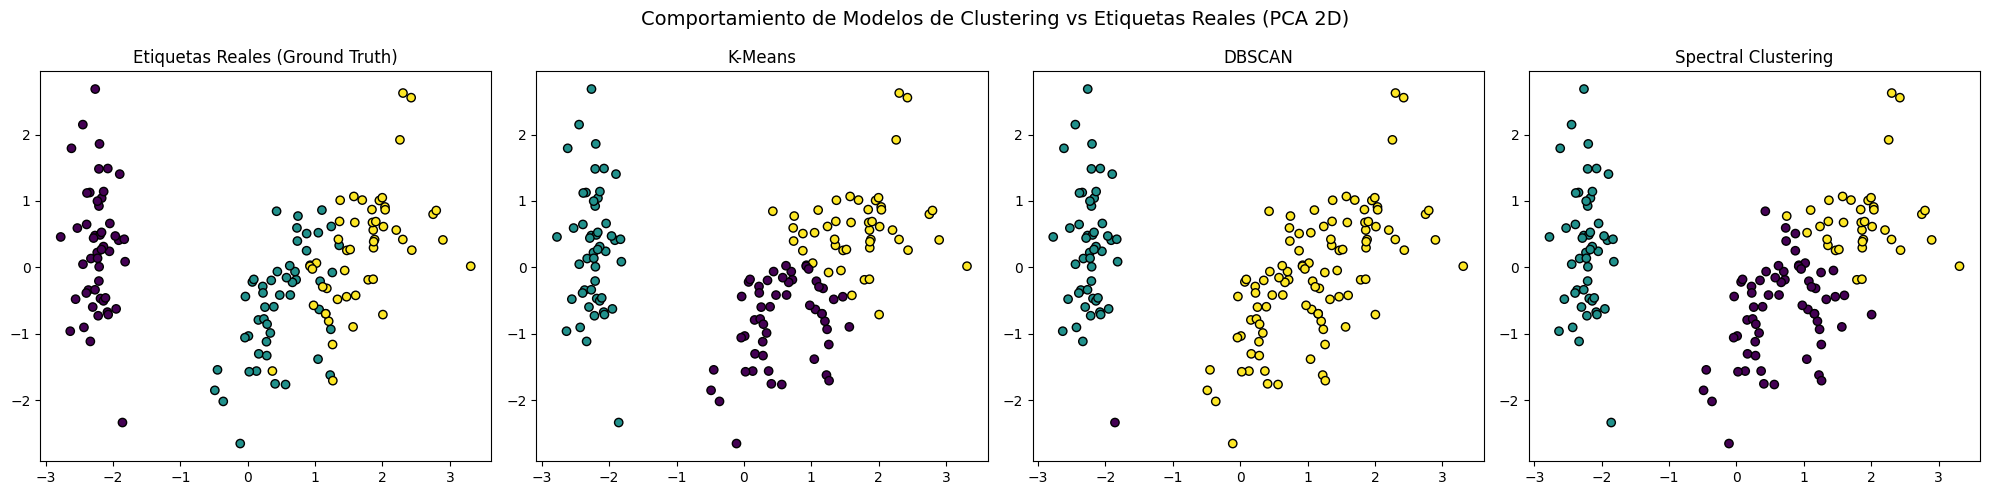


=== NATURALEZA DE LOS MODELOS ===
K-Means: LINEAL - Fronteras hiperplanos
DBSCAN: NO LINEAL - Basado en densidad
Spectral Clustering: NO LINEAL - Basado en grafos/afinidad


In [16]:
# 5. Visualización del Comportamiento (Reducción a 2D con PCA)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Comportamiento de Modelos de Clustering vs Etiquetas Reales (PCA 2D)', fontsize=14)

# Plot Ground Truth
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', edgecolor='k')
axes[0].set_title('Etiquetas Reales (Ground Truth)')

# Plot Modelos
for ax, (name, y_pred) in zip(axes[1:], predictions.items()):
    # DBSCAN marca el ruido con -1. Usamos un mapa de color que lo resalte (ej. negro).
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='viridis', edgecolor='k')
    ax.set_title(name)

plt.tight_layout()
plt.show()

#Conclusiones
print("\n=== NATURALEZA DE LOS MODELOS ===")
print("K-Means: LINEAL - Fronteras hiperplanos")
print("DBSCAN: NO LINEAL - Basado en densidad")
print("Spectral Clustering: NO LINEAL - Basado en grafos/afinidad")